<a href="https://colab.research.google.com/github/sumayya966/casestudy2/blob/main/Housepricing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [152]:
import pandas as pd
import numpy as np
import math
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer

#1. Dataset Overview

In [153]:
df = pd.read_csv("/content/sample_data/House_Pricing (1).csv")

In [154]:
df.head()

,ID,Date House was Sold,Sale Price,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Waterfront View,No of Times Visited,...,Overall Grade,Area of the House from Basement (in Sqft),Basement Area (in Sqft),Age of House (in Years),Renovated Year,Zipcode,Latitude,Longitude,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft)
0,7129300520,14 October 2017,221900.0,3,1.00,1180.0,5650.0,1.0,No,NaN,...,7,1180.0,0,63,0,98178.0,47.5112,-122.257,1340.0,5650
1,6414100192,14 December 2017,538000.0,3,2.25,2570.0,7242.0,2.0,No,NaN,...,7,2170.0,400,67,1991,98125.0,47.7210,-122.319,1690.0,7639
2,5631500400,15 February 2016,180000.0,2,1.00,770.0,10000.0,1.0,No,NaN,...,6,770.0,0,85,0,98028.0,47.7379,-122.233,2720.0,8062
3,2487200875,14 December 2017,604000.0,4,3.00,1960.0,5000.0,1.0,No,NaN,...,7,1050.0,910,53,0,98136.0,47.5208,-122.393,1360.0,5000
4,1954400510,15 February 2016,510000.0,3,2.00,1680.0,8080.0,1.0,No,NaN,...,8,1680.0,0,31,0,98074.0,47.6168,-122.045,1800.0,7503


In [155]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   ID                                         21613 non-null  int64  
 1   Date House was Sold                        21613 non-null  object 
 2   Sale Price                                 21609 non-null  float64
 3   No of Bedrooms                             21613 non-null  int64  
 4   No of Bathrooms                            21609 non-null  float64
 5   Flat Area (in Sqft)                        21604 non-null  float64
 6   Lot Area (in Sqft)                         21604 non-null  float64
 7   No of Floors                               21613 non-null  float64
 8   Waterfront View                            21613 non-null  object 
 9   No of Times Visited                        2124 non-null   object 
 10  Condition of the House

In [156]:
df.describe()

,ID,Sale Price,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Overall Grade,Area of the House from Basement (in Sqft),Basement Area (in Sqft),Age of House (in Years),Renovated Year,Zipcode,Latitude,Longitude,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft)
count,2.161300e+04,2.160900e+04,21613.000000,21609.000000,21604.000000,2.160400e+04,21613.000000,21613.000000,21610.000000,21613.000000,21613.000000,21613.000000,21612.000000,21612.000000,21612.000000,21612.000000,21613.000000
mean,4.580302e+09,5.401984e+05,3.370842,2.114732,2079.931772,1.510776e+04,1.494309,7.623467,1788.344193,291.509045,46.994864,84.402258,98077.937766,47.560048,-122.213892,1986.538914,12768.455652
std,2.876566e+09,3.673890e+05,0.930062,0.770138,918.487597,4.142827e+04,0.539989,1.105439,827.982604,442.575043,29.373411,401.679240,53.505425,0.138565,0.140830,685.404255,27304.179631
min,1.000102e+06,7.500000e+04,0.000000,0.000000,290.000000,5.200000e+02,1.000000,1.000000,290.000000,0.000000,3.000000,0.000000,98001.000000,47.155900,-122.519000,399.000000,651.000000
25%,2.123049e+09,3.219500e+05,3.000000,1.750000,1429.250000,5.040000e+03,1.000000,7.000000,1190.000000,0.000000,21.000000,0.000000,98033.000000,47.470975,-122.328000,1490.000000,5100.000000
50%,3.904930e+09,4.500000e+05,3.000000,2.250000,1910.000000,7.617500e+03,1.500000,7.000000,1560.000000,0.000000,43.000000,0.000000,98065.000000,47.571800,-122.230000,1840.000000,7620.000000
75%,7.308900e+09,6.450000e+05,4.000000,2.500000,2550.000000,1.068825e+04,2.000000,8.000000,2210.000000,560.000000,67.000000,0.000000,98118.000000,47.678000,-122.125000,2360.000000,10083.000000
max,9.900000e+09,7.700000e+06,33.000000,8.000000,13540.000000,1.651359e+06,3.500000,10.000000,9410.000000,4820.000000,118.000000,2015.000000,98199.000000,47.777600,-121.315000,6210.000000,871200.000000


#2. Duplicate Removal

In [157]:
# Check duplicate rows
duplicate_rows = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_rows)

# Remove duplicate rows
df = df.drop_duplicates()

print("Shape after removing duplicate rows:", df.shape)

Number of duplicate rows: 0
Shape after removing duplicate rows: (21613, 21)


In [158]:
# Find duplicate columns based on their values

duplicate_columns = []

columns = df.columns

for i in range(len(columns)):
    for j in range(i + 1, len(columns)):
        if df[columns[i]].equals(df[columns[j]]):
            duplicate_columns.append(columns[j])

print("Duplicate columns:", duplicate_columns)

# Drop duplicate columns
df = df.drop(columns=duplicate_columns)

print("Shape after removing duplicate columns:", df.shape)


Duplicate columns: []
Shape after removing duplicate columns: (21613, 21)


#3. Handling Missing Values


In [159]:
# Count missing values
missing_values = df.isnull().sum()

print("MISSING VALUES")
print(missing_values[missing_values > 0])

MISSING VALUES
Sale Price                                       4
No of Bathrooms                                  4
Flat Area (in Sqft)                              9
Lot Area (in Sqft)                               9
No of Times Visited                          19489
Area of the House from Basement (in Sqft)        3
Zipcode                                          1
Latitude                                         1
Longitude                                        1
Living Area after Renovation (in Sqft)           1
dtype: int64


In [160]:
# Identify numerical and categorical columns
numerical_columns = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_columns = df.select_dtypes(include=['object', 'category']).columns.tolist()

print("Numerical columns:")
print(numerical_columns)

print("\nCategorical columns:")
print(categorical_columns)

Numerical columns:
['ID', 'Sale Price', 'No of Bedrooms', 'No of Bathrooms', 'Flat Area (in Sqft)', 'Lot Area (in Sqft)', 'No of Floors', 'Overall Grade', 'Area of the House from Basement (in Sqft)', 'Basement Area (in Sqft)', 'Age of House (in Years)', 'Renovated Year', 'Zipcode', 'Latitude', 'Longitude', 'Living Area after Renovation (in Sqft)', 'Lot Area after Renovation (in Sqft)']

Categorical columns:
['Date House was Sold', 'Waterfront View', 'No of Times Visited', 'Condition of the House']


In [161]:
# Store documentation of imputation
imputation_log = {}

# Numerical columns - median imputation
for col in numerical_columns:
    if df[col].isnull().sum() > 0:
        median_value = df[col].median()
        df[col] = df[col].fillna(median_value)

        imputation_log[col] = f"Numerical -> Median ({median_value})"

# Categorical columns - mode imputation
for col in categorical_columns:
    if df[col].isnull().sum() > 0:
        mode_value = df[col].mode()[0]
        df[col] = df[col].fillna(mode_value)

        imputation_log[col] = f"Categorical -> Mode ({mode_value})"

print(" IMPUTATION APPROACH ")

for col, method in imputation_log.items():
    print(f"{col}: {method}")

 IMPUTATION APPROACH 
Sale Price: Numerical -> Median (450000.0)
No of Bathrooms: Numerical -> Median (2.25)
Flat Area (in Sqft): Numerical -> Median (1910.0)
Lot Area (in Sqft): Numerical -> Median (7617.5)
Area of the House from Basement (in Sqft): Numerical -> Median (1560.0)
Zipcode: Numerical -> Median (98065.0)
Latitude: Numerical -> Median (47.5718)
Longitude: Numerical -> Median (-122.23)
Living Area after Renovation (in Sqft): Numerical -> Median (1840.0)
No of Times Visited: Categorical -> Mode (Twice)


In [162]:
print("\n MISSING VALUES AFTER IMPUTATION ")
print(df.isnull().sum().sum())

print("\n Missing values by column:")
print(df.isnull().sum())


 MISSING VALUES AFTER IMPUTATION 
0

 Missing values by column:
ID                                           0
Date House was Sold                          0
Sale Price                                   0
No of Bedrooms                               0
No of Bathrooms                              0
Flat Area (in Sqft)                          0
Lot Area (in Sqft)                           0
No of Floors                                 0
Waterfront View                              0
No of Times Visited                          0
Condition of the House                       0
Overall Grade                                0
Area of the House from Basement (in Sqft)    0
Basement Area (in Sqft)                      0
Age of House (in Years)                      0
Renovated Year                               0
Zipcode                                      0
Latitude                                     0
Longitude                                    0
Living Area after Renovation (in Sqft)    

In [163]:
df = df.drop("ID", axis=1)

In [164]:
# Convert date column to datetime
df['Date House was Sold'] = pd.to_datetime(
    df['Date House was Sold'],
    errors='coerce'
)

# Extract useful date features
df['Sale Year'] = df['Date House was Sold'].dt.year
df['Sale Month'] = df['Date House was Sold'].dt.month
df['Sale Day'] = df['Date House was Sold'].dt.day

# Drop original date column
df = df.drop(columns=['Date House was Sold'])

print(df.head())

   Sale Price  No of Bedrooms  No of Bathrooms  Flat Area (in Sqft)  \
0    221900.0               3             1.00               1180.0   
1    538000.0               3             2.25               2570.0   
2    180000.0               2             1.00                770.0   
3    604000.0               4             3.00               1960.0   
4    510000.0               3             2.00               1680.0   

   Lot Area (in Sqft)  No of Floors Waterfront View No of Times Visited  \
0              5650.0           1.0              No               Twice   
1              7242.0           2.0              No               Twice   
2             10000.0           1.0              No               Twice   
3              5000.0           1.0              No               Twice   
4              8080.0           1.0              No               Twice   

  Condition of the House  Overall Grade  ...  Age of House (in Years)  \
0                   Fair              7  ...     

#4. Outlier Detection Using IQR


In [165]:
# Target variable
target = 'Sale Price'

# Numerical predictor columns
numerical_features = df.select_dtypes(
    include=['int64', 'float64']
).columns.tolist()

# Remove target from predictor list
numerical_features = [
    col for col in numerical_features
    if col != target
]

print("Numerical features:")
print(numerical_features)

Numerical features:
['No of Bedrooms', 'No of Bathrooms', 'Flat Area (in Sqft)', 'Lot Area (in Sqft)', 'No of Floors', 'Overall Grade', 'Area of the House from Basement (in Sqft)', 'Basement Area (in Sqft)', 'Age of House (in Years)', 'Renovated Year', 'Zipcode', 'Latitude', 'Longitude', 'Living Area after Renovation (in Sqft)', 'Lot Area after Renovation (in Sqft)']


In [166]:
# Dictionary to store number of outliers
outlier_counts = {}

for col in numerical_features:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[
        (df[col] < lower_bound) |
        (df[col] > upper_bound)
    ]

    outlier_counts[col] = len(outliers)

# Display outlier counts
outlier_df = pd.DataFrame(
    list(outlier_counts.items()),
    columns=['Feature', 'Number of Outliers']
)

outlier_df = outlier_df.sort_values(
    by='Number of Outliers',
    ascending=False
)

display(outlier_df)

,Feature,Number of Outliers
3,Lot Area (in Sqft),2423
14,Lot Area after Renovation (in Sqft),2194
5,Overall Grade,1911
9,Renovated Year,914
6,Area of the House from Basement (in Sqft),610
2,Flat Area (in Sqft),572
1,No of Bathrooms,571
0,No of Bedrooms,546
13,Living Area after Renovation (in Sqft),544
7,Basement Area (in Sqft),496


In [167]:
# Create a copy before removing outliers
df_clean = df.copy()

for col in numerical_features:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    df_clean = df_clean[
        (df_clean[col] >= lower_bound) &
        (df_clean[col] <= upper_bound)
    ]

print("Original number of rows:", len(df))
print("Rows after outlier removal:", len(df_clean))
print("Rows removed:", len(df) - len(df_clean))

Original number of rows: 21613
Rows after outlier removal: 15103
Rows removed: 6510


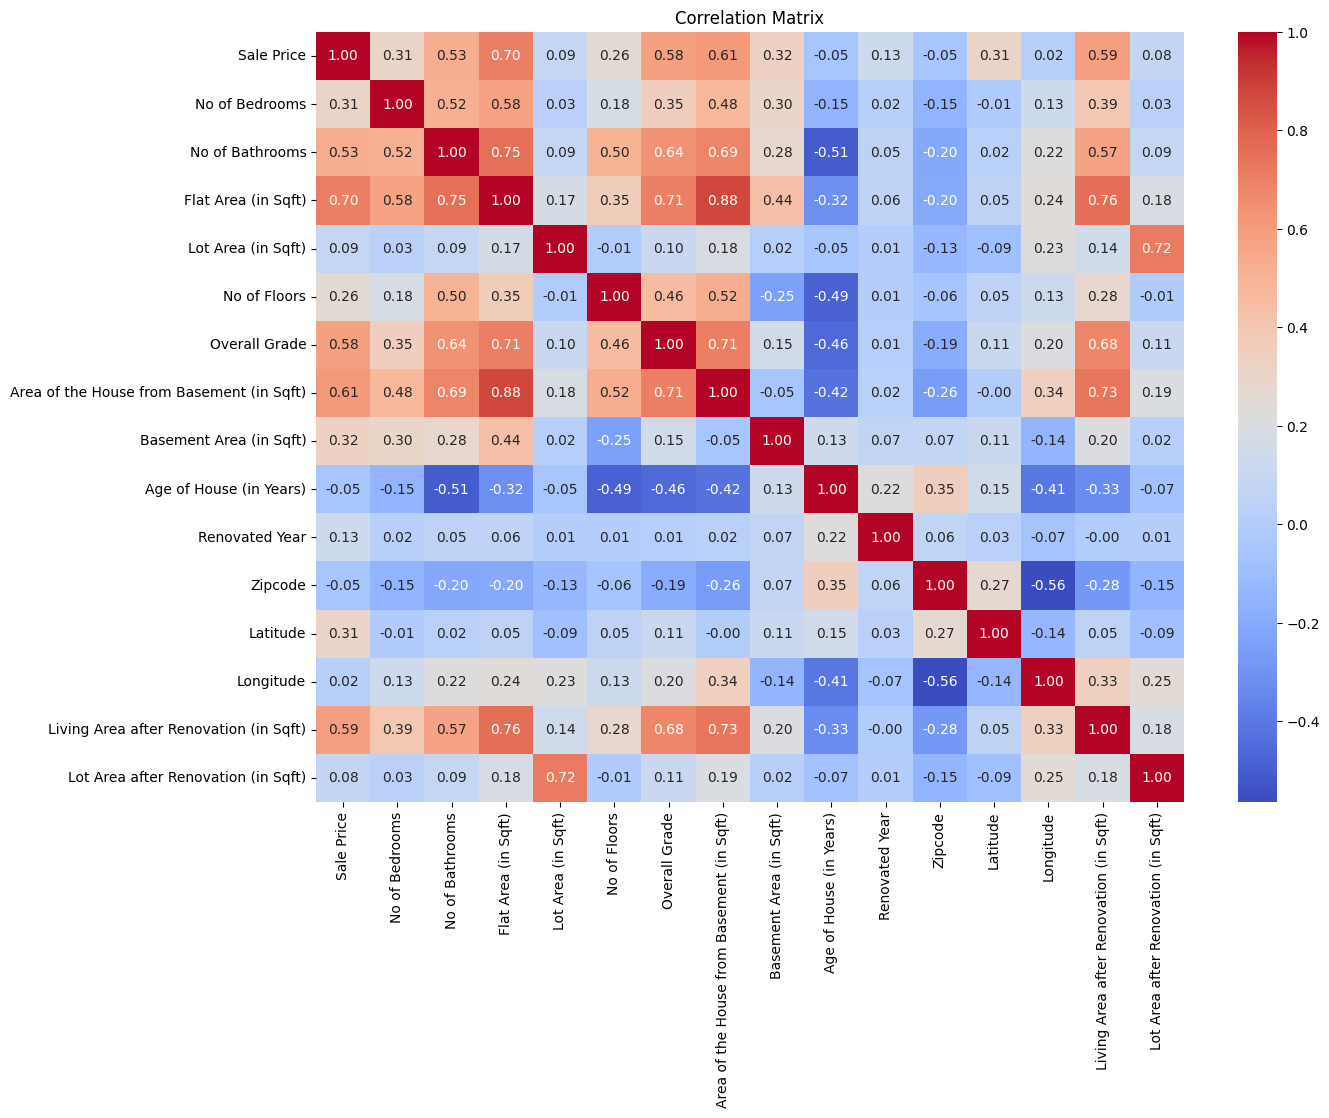

In [168]:
# Numerical columns
numerical_data = df.select_dtypes(include=['int64', 'float64'])

# Correlation matrix
corr = numerical_data.corr()

# Correlation heatmap
plt.figure(figsize=(14, 10))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Correlation Matrix")
plt.show()

#5. Encoding Categorical Variables


In [169]:
# Display unique values in categorical columns
for col in categorical_features:
    print(f"\n{col}")
    print(X[col].unique())


Waterfront View
['No' 'Yes']

No of Times Visited
['Twice' 'Thrice' 'Once' 'Four']

Condition of the House
['Fair' 'Excellent' 'Good' 'Okay' 'Bad']


In [170]:
# One-hot encode categorical variables
encoder = OneHotEncoder(
    handle_unknown='ignore',
    sparse_output=False
)

X_encoded = encoder.fit_transform(X[categorical_features])

# Convert encoded values into DataFrame
encoded_columns = encoder.get_feature_names_out(categorical_features)

X_encoded_df = pd.DataFrame(
    X_encoded,
    columns=encoded_columns,
    index=X.index
)

# Numerical data
X_numerical = X[numerical_features].reset_index(drop=True)

# Combine numerical and encoded categorical features
X_final = pd.concat(
    [
        X_numerical.reset_index(drop=True),
        X_encoded_df.reset_index(drop=True)
    ],
    axis=1
)

print("Shape after encoding:", X_final.shape)

X_final.head()


Shape after encoding: (15103, 26)


,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Overall Grade,Area of the House from Basement (in Sqft),Basement Area (in Sqft),Age of House (in Years),Renovated Year,...,Waterfront View_Yes,No of Times Visited_Four,No of Times Visited_Once,No of Times Visited_Thrice,No of Times Visited_Twice,Condition of the House_Bad,Condition of the House_Excellent,Condition of the House_Fair,Condition of the House_Good,Condition of the House_Okay
0,3,1.00,1180.0,5650.0,1.0,7,1180.0,0,63,0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
1,2,1.00,770.0,10000.0,1.0,6,770.0,0,85,0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
2,4,3.00,1960.0,5000.0,1.0,7,1050.0,910,53,0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
3,3,2.00,1680.0,8080.0,1.0,8,1680.0,0,31,0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
4,3,2.25,1715.0,6819.0,2.0,7,1715.0,0,23,0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0


#6. Train-Test Split

In [171]:
# Split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X_final,
    y,
    test_size=0.20,
    random_state=42
)

print("TRAIN-TEST SPLIT ")

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

TRAIN-TEST SPLIT 
X_train shape: (12082, 26)
X_test shape: (3021, 26)
y_train shape: (12082,)
y_test shape: (3021,)


#7. Scale Numerical Variables

In [172]:
# Standard scaler
scaler = StandardScaler()

X_final[numerical_features] = scaler.fit_transform(
    X_final[numerical_features]
)

print("Numerical variables have been standardized.")

X_final.head()

Numerical variables have been standardized.


,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Overall Grade,Area of the House from Basement (in Sqft),Basement Area (in Sqft),Age of House (in Years),Renovated Year,...,Waterfront View_Yes,No of Times Visited_Four,No of Times Visited_Once,No of Times Visited_Thrice,No of Times Visited_Twice,Condition of the House_Bad,Condition of the House_Excellent,Condition of the House_Fair,Condition of the House_Good,Condition of the House_Okay
0,-0.316847,-1.486052,-1.046435,-0.378693,-0.830147,-0.467238,-0.664010,-0.688954,0.501893,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
1,-1.617566,-1.486052,-1.747724,0.970542,-0.830147,-1.722209,-1.412991,-0.688954,1.250106,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
2,0.983871,1.612642,0.287725,-0.580303,-0.830147,-0.467238,-0.901492,1.835906,0.161795,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
3,-0.316847,0.063295,-0.191204,0.375017,-0.830147,0.787732,0.249381,-0.688954,-0.586418,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
4,-0.316847,0.450632,-0.131338,-0.016106,0.993255,-0.467238,0.313318,-0.688954,-0.858496,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
